In [49]:
# ==============================
#  DERMATOLOGY AI PROJECT SETUP
# ==============================

import os
import zipfile
import numpy as np
import tensorflow as tf
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define project path
PROJECT_PATH = "/content/drive/MyDrive/Dermatology_AI_Project"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# ZIP file paths
ISIC_ZIP = f"{DATASET_PATH}/ISIC2018_segmentation.zip"
HAM_ZIP = f"{DATASET_PATH}/HAM10000.zip"

print("Project Path:", PROJECT_PATH)
print("Dataset Path:", DATASET_PATH)

# Move to project directory
os.chdir(PROJECT_PATH)
print("Current Working Directory:", os.getcwd())

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project Path: /content/drive/MyDrive/Dermatology_AI_Project
Dataset Path: /content/drive/MyDrive/Dermatology_AI_Project/datasets
Current Working Directory: /content/drive/MyDrive/Dermatology_AI_Project


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [3]:
model_path = "/content/drive/MyDrive/Dermatology_AI_Project/models/mobilenet_finetuned_final.keras"

model = load_model(model_path)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 31 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,646,480 (13.91 MB)

 Trainable params: 1,379,527 (5.26 MB)

 Non-trainable params: 887,424 (3.39 MB)

 Optimizer params: 1,379,529 (5.26 MB)

In [14]:
for layer in model.layers:
    print(layer.name)

input_layer
Conv1
bn_Conv1
Conv1_relu
expanded_conv_depthwise
expanded_conv_depthwise_BN
expanded_conv_depthwise_relu
expanded_conv_project
expanded_conv_project_BN
block_1_expand
block_1_expand_BN
block_1_expand_relu
block_1_pad
block_1_depthwise
block_1_depthwise_BN
block_1_depthwise_relu
block_1_project
block_1_project_BN
block_2_expand
block_2_expand_BN
block_2_expand_relu
block_2_depthwise
block_2_depthwise_BN
block_2_depthwise_relu
block_2_project
block_2_project_BN
block_2_add
block_3_expand
block_3_expand_BN
block_3_expand_relu
block_3_pad
block_3_depthwise
block_3_depthwise_BN
block_3_depthwise_relu
block_3_project
block_3_project_BN
block_4_expand
block_4_expand_BN
block_4_expand_relu
block_4_depthwise
block_4_depthwise_BN
block_4_depthwise_relu
block_4_project
block_4_project_BN
block_4_add
block_5_expand
block_5_expand_BN
block_5_expand_relu
block_5_depthwise
block_5_depthwise_BN
block_5_depthwise_relu
block_5_project
block_5_project_BN
block_5_add
block_6_expand
block_6_ex

In [25]:
class_labels = [
    "Melanoma",
    "Melanocytic Nevus",
    "Basal Cell Carcinoma",
    "Benign Keratosis",
    "Dermatofibroma",
    "Vascular Lesion",
    "Actinic Keratosis"
]

In [26]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [27]:
import os

image_folder = "/content/drive/MyDrive/Dermatology_AI_Project/test_images"

image_list = os.listdir(image_folder)

img_path = os.path.join(image_folder, image_list[0])

print("Using image:", img_path)

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))

img_array = tf.keras.preprocessing.image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

Using image: /content/drive/MyDrive/Dermatology_AI_Project/test_images/lesion.jpg


In [28]:
last_conv_layer_name = "Conv_1"

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

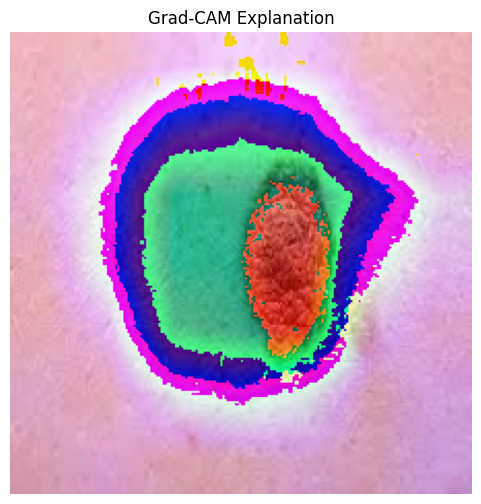

In [29]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img.astype("uint8"), cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Explanation")
plt.axis("off")
plt.show()

In [30]:
import os

results_dir = "/content/drive/MyDrive/Dermatology_AI_Project/results/gradcam_outputs"

os.makedirs(results_dir, exist_ok=True)

print("Grad-CAM results will be saved in:", results_dir)

Grad-CAM results will be saved in: /content/drive/MyDrive/Dermatology_AI_Project/results/gradcam_outputs


In [31]:
image_folder = "/content/drive/MyDrive/Dermatology_AI_Project/test_images"

image_list = os.listdir(image_folder)

print("Total images:", len(image_list))

Total images: 2


In [32]:
def preprocess_image(img_path):

    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))

    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = img_array / 255.0

    return img_array

In [33]:
def generate_gradcam(img_path, model, last_conv_layer_name):

    img_array = preprocess_image(img_path)

    preds = model.predict(img_array)

    pred_class = np.argmax(preds[0])
    confidence = np.max(preds[0])

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img

    return superimposed_img, pred_class, confidence

In [34]:
last_conv_layer_name = "Conv_1"

for i, image_name in enumerate(image_list):

    img_path = os.path.join(image_folder, image_name)

    result_img, pred_class, confidence = generate_gradcam(
        img_path,
        model,
        last_conv_layer_name
    )

    save_path = os.path.join(results_dir, f"gradcam_{image_name}")

    cv2.imwrite(save_path, result_img)

    print(f"Processed {image_name}")
    print(f"Prediction: {class_labels[pred_class]} | Confidence: {confidence:.2f}")
    print("Saved to:", save_path)
    print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Processed lesion.jpg
Prediction: Vascular Lesion | Confidence: 0.98
Saved to: /content/drive/MyDrive/Dermatology_AI_Project/results/gradcam_outputs/gradcam_lesion.jpg
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Processed lesion2.jpg
Prediction: Vascular Lesion | Confidence: 0.64
Saved to: /content/drive/MyDrive/Dermatology_AI_Project/results/gradcam_outputs/gradcam_lesion2.jpg
----------------------------------------


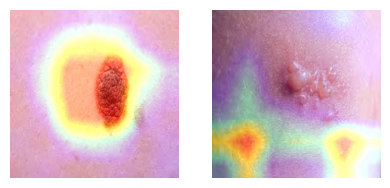

In [36]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10,5))

for i in range(min(4, len(image_list))):

    img_path = os.path.join(results_dir, f"gradcam_{image_list[i]}")

    if not os.path.exists(img_path):
        print("File not found:", img_path)
        continue

    img = cv2.imread(img_path)

    if img is None:
        print("Could not load image:", img_path)
        continue

    plt.subplot(1,4,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.show()

In [51]:
seg_model_path = "/content/drive/MyDrive/Dermatology_AI_Project/models/unet_segmentation_best.h5"

seg_model = tf.keras.models.load_model(seg_model_path, compile=False)

print("Segmentation model loaded successfully")

Segmentation model loaded successfully


In [59]:
def get_segmentation_mask(img_path):

    # load image for segmentation
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict mask
    pred_mask = seg_model.predict(img_array)[0]

    mask = (pred_mask > 0.5).astype(np.uint8)

    # resize mask to match classifier image size
    mask = cv2.resize(mask, (224,224))

    return mask

In [62]:
def explainable_dashboard(img_path):

    # ORIGINAL IMAGE
    original = cv2.imread(img_path)
    original = cv2.resize(original,(224,224))

    # SEGMENTATION
    mask = get_segmentation_mask(img_path)

    # GRADCAM
    img_array = preprocess_image(img_path)
    heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")

    heatmap = cv2.resize(heatmap,(224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # ROI
    roi_score = compute_roi_attention_score(mask, heatmap)

    # FINAL OVERLAY
    fusion = heatmap_color * 0.4 + original

    # PREDICTION
    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    confidence = np.max(preds[0])

    diagnosis = class_labels[pred_class]

    # PLOT DASHBOARD
    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Lesion Segmentation")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Attention")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(cv2.cvtColor(fusion.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.title(f"{diagnosis} ({confidence:.2f}) | ROI Score: {roi_score:.2f}")
    plt.axis("off")

    plt.show()

In [64]:
def compute_roi_attention_score(mask, heatmap):

    # normalize heatmap
    heatmap = heatmap / np.max(heatmap)

    # resize mask if needed
    mask = cv2.resize(mask, (224,224))

    mask = (mask > 0.5).astype(np.float32)

    # GradCAM attention inside lesion
    inside_attention = np.sum(heatmap * mask)

    # total attention
    total_attention = np.sum(heatmap)

    roi_score = inside_attention / (total_attention + 1e-8)

    return roi_score

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


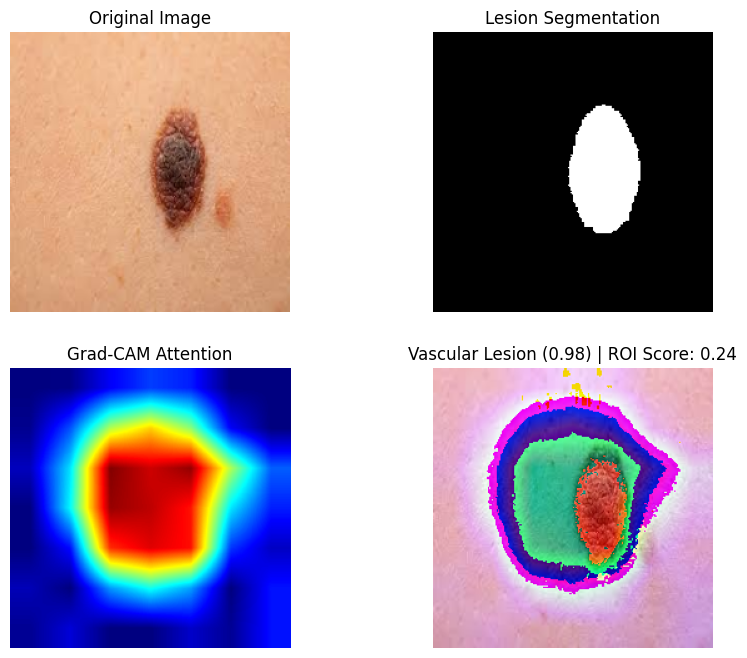

In [65]:
explainable_dashboard(
"/content/drive/MyDrive/Dermatology_AI_Project/test_images/lesion.jpg"
)

In [66]:
dashboard_dir = "/content/drive/MyDrive/Dermatology_AI_Project/results/explainability_dashboards"

os.makedirs(dashboard_dir, exist_ok=True)

print("Dashboard folder ready:", dashboard_dir)

Dashboard folder ready: /content/drive/MyDrive/Dermatology_AI_Project/results/explainability_dashboards


In [69]:
def save_explainable_dashboard(img_path):

    original = cv2.imread(img_path)
    original = cv2.resize(original,(224,224))

    mask = get_segmentation_mask(img_path)

    img_array = preprocess_image(img_path)

    heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
    heatmap = cv2.resize(heatmap,(224,224))

    roi_score = compute_roi_attention_score(mask, heatmap)

    heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

    fusion = heatmap_color*0.4 + original

    preds = model.predict(img_array)

    pred_class = np.argmax(preds[0])
    confidence = np.max(preds[0])

    diagnosis = class_labels[pred_class]

    fig = plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Segmentation")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB))
    plt.title("GradCAM")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(cv2.cvtColor(fusion.astype("uint8"), cv2.COLOR_BGR2RGB))
    plt.title(f"{diagnosis} ({confidence:.2f}) | ROI:{roi_score:.2f}")
    plt.axis("off")

    filename = os.path.basename(img_path)

    save_path = os.path.join(dashboard_dir, f"dashboard_{filename}")

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved dashboard:", save_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


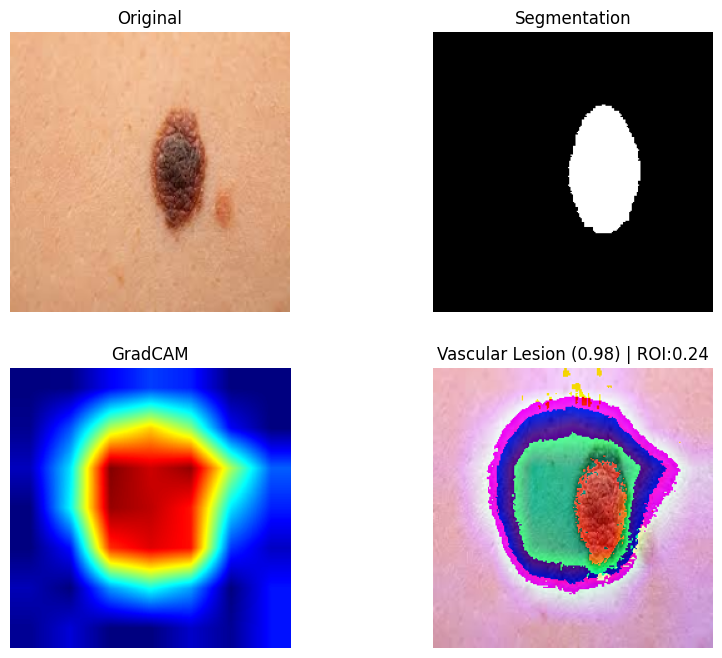

Saved dashboard: /content/drive/MyDrive/Dermatology_AI_Project/results/explainability_dashboards/dashboard_lesion.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


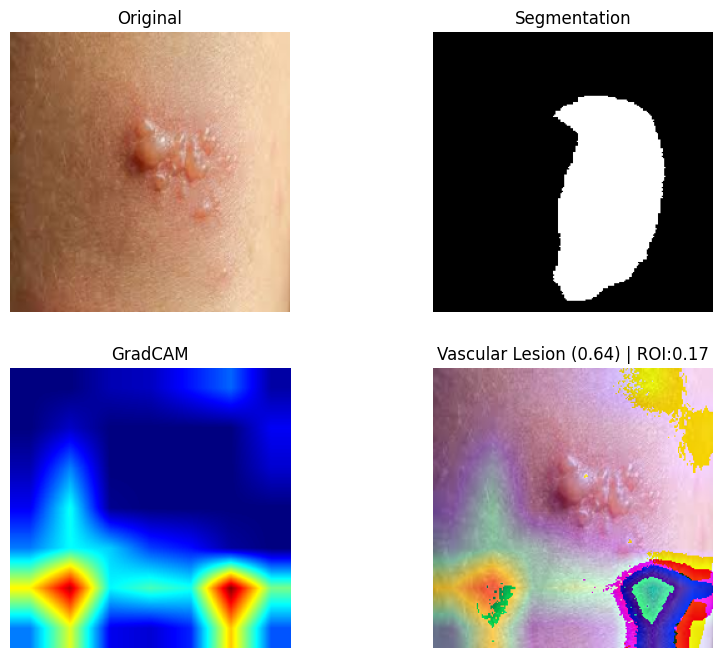

Saved dashboard: /content/drive/MyDrive/Dermatology_AI_Project/results/explainability_dashboards/dashboard_lesion2.jpg


In [70]:
for image_name in image_list:

    img_path = os.path.join(image_folder, image_name)

    save_explainable_dashboard(img_path)

In [71]:
import pandas as pd

roi_results = []

for image_name in image_list:

    img_path = os.path.join(image_folder, image_name)

    mask = get_segmentation_mask(img_path)

    img_array = preprocess_image(img_path)

    heatmap = make_gradcam_heatmap(img_array, model, "Conv_1")
    heatmap = cv2.resize(heatmap,(224,224))

    roi_score = compute_roi_attention_score(mask, heatmap)

    roi_results.append({
        "image": image_name,
        "roi_attention_score": roi_score
    })

df = pd.DataFrame(roi_results)

save_path = "/content/drive/MyDrive/Dermatology_AI_Project/results/roi_attention_scores.csv"

df.to_csv(save_path, index=False)

print("ROI scores saved to:", save_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
ROI scores saved to: /content/drive/MyDrive/Dermatology_AI_Project/results/roi_attention_scores.csv
